# Домашнее задание 2: DPO и PPO

В этой домашке поближе познакомимся с двумя крайне популярными методами алаймента языковых моделей. В первой части вам предоставится возможность самостоятельно заимплементить DPO c нуля. Во второй части мы уже будем использовать библиотеку TRL и обучим PPO.

Обученные модели можно и нужно выложить на [🤗 HuggingFace](https://huggingface.co/). Зарегистрируйтесь там, подпишитесь на [deep vk](https://huggingface.co/deepvk) и создайте себе API токен.

Следуйте ячейкам тетрадки и заполняйте пропущенные ячейки. В конце тетрадки вы найдете задачи со звездочкой, чтобы получить максимальный балл!

## Импорты и вспомогательные функции

In [ ]:
# Установим необходимые дополнительные библиотеки

# %pip install datasets trl wandb transformers

In [2]:
# Необходимые импорты (для обоих частей)
import os
import inspect
import random
from functools import partial

import numpy as np
import gc
import torch
import torch.nn.functional as F
from datasets import load_dataset
from huggingface_hub import HfApi, interpreter_login
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from transformers import (
    AutoModelForCausalLM,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    PreTrainedTokenizerBase,
)
from trl import PPOConfig, PPOTrainer, RewardConfig, RewardTrainer

In [3]:
interpreter_login()


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|



/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Enter your token (input will not be visible): ··········
Add token as git credential? (Y/n) n


In [4]:
# Подготовим репозиторий для будущей модели и токенизатора
username = HfApi().whoami()["name"]
REPO_NAME = f"{username}/llm-course-hw2"  # Или как вам хочется

print(f"Homework repository: '{REPO_NAME}'")

Homework repository: 'CTOHbl4/llm-course-hw2'


In [5]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

set_seed(42)


# Этой функцией будут помечены все места, которые необходимо дозаполнить
# Это могут быть как целые функции, так и отдельные части внутри них
# Всегда можно воспользоваться интроспекцией и найти места использования этой функции :)
def todo():
    stack = inspect.stack()
    caller_frame = stack[1]
    function_name = caller_frame.function
    line_number = caller_frame.lineno
    raise NotImplementedError(f"TODO at {function_name}, line {line_number}")


def disable_dropout_in_model(model):
    for module in model.modules():
        if isinstance(module, torch.nn.Dropout):
            module.p = 0

# Часть 1: DPO

Крайне простой метод, который в свое время произвел фурор, т.к. выгодно выделялся на фоне PPO. В отличие от PPO, требующего отдельно обучать Reward Model, Value Model и больших усилий в имплементации, DPO не требует явной ревард модели, а только датасета с человеческими преференсами вида: промпт, выбранный человеком ответ, отвергнутный человеком ответ. Простота также видна из лосса, по сути это весь метод:
$$
L_\text{DPO}(\pi_{\theta}; \pi_\text{ref}) = -E_{(x, y_w, y_l)\sim D}\left[\log \sigma \left(
\beta \log \frac{\pi_{\theta}(y_w\mid x)}{\pi_\text{ref}(y_w\mid x)} \thinspace
{- \beta \log \frac{\pi_{\theta}(y_l\mid x)}{\pi_\text{ref}(y_l\mid x)}}\right)\right]
$$

где:

- $\pi_{\theta}$ LLM которую мы хотим заалайнить
- $\pi_\text{ref}$ референсная модель для регуляризации, как правило просто начальный чекпоинт
- $D$ датасет с преференсами
- $x$ промпт из датасета $D$
- $y_w$ ответ на промпт $x$ выбранный человеком (или тем кто размечал преференсы, это может быть и большая LLM)
- $y_l$ ответ на промпт $x$ отвергнутый человеком (или тем кто размечал преференсы, это может быть и большая LLM)
- $\beta$ гиперепараметр отвечающий за то, как далеко мы можем отходить от референсной модели

Во время имплементации советум внимательно прочитать оригинальную статью: [Direct Preference Optimization: Your Language Model is Secretly a Reward Model](https://arxiv.org/abs/2305.18290).

Для файнтюна мы будем использовать модель [HuggingFaceTB/SmolLM-135M-Instruct](https://huggingface.co/HuggingFaceTB/SmolLM-135M-Instruct), т.к. она маленького размера (поместится на Colab), но при этом умеет достаточно, чтобы увидеть изменения от алаймента. Более того, данная модель даже прошла стадию SFT, а поэтому в отличие от базовой модели (без Instruct) понимает формат чата (chat-template в transformers, дальше разберем) и имеет 'осознание' себя языковым ассистентом.

P.S. Если у вас есть доступ к вычислительным ресурсам типо A100 и больше, вы можете попробовать зафайнтюнить модель большего размера из этой же [линейки](https://huggingface.co/blog/smollm). Будьте внимательны, смотрите, чтобы она была с добавкой Instruct.

In [6]:
MODEL_ID = "HuggingFaceTB/SmolLM-135M-Instruct"
DATASET_ID = "HumanLLMs/Human-Like-DPO-Dataset"

## Подготовка данных [2 балла]

Для начала нужно подготовить данные. В качестве датасета преференсов мы будем использовать [HumanLLMs/Human-Like-DPO-Dataset](https://huggingface.co/datasets/HumanLLMs/Human-Like-DPO-Dataset), который значительно повышает эмоциональность модели, количество используемых эмодзи и в целом снижает строгость следования шаблону "As a conversational AI, I ...".

Чтобы подготовить датасет нужно несколько простых этапов:
1. Привест данные к формату chat-template
2. После применить этот chat-template с помощью 'tokenizer.apply_chat_template'
3. Токенизировать получившиеся данные, попутно обрезав промпт и ответы до нужной длины, если надо.

Внимательно прочитайте [документацию по chat-templates](https://huggingface.co/docs/transformers/chat_templating). Для удобства данные приводят в начале в более верхне-уровневый формат такого вида:
```python
messages = [
    {"role": "system", "content": "You are a helpful assistant focused on technical topics."},
    {"role": "user", "content": "Can you explain what a chat template is?"},
    {"role": "assistant", "content": "A chat template structures conversations between users and AI models..."}
]
```
То есть модели можно задать разные роли, такие как например системный промпт, и в целом структурировать диалог между ассистентом и человеком. Обычно обучение этому происходит на этапе SFT. Данная репрезентация абстрагирует детали (конкретные токены) как этот формат используют разные модели. Чтобы перевести его в неспоредственно текстовый инпут в формате специфичном конкретной модели используется `tokenizer.apply_chat_template`.

In [ ]:
# понадобится для подготовки данных
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

In [ ]:
dataset = load_dataset(DATASET_ID, split="train")
dataset[0]

{'prompt': 'Oh, I just saw the best meme - have you seen it?',
 'chosen': "😂 Ah, no I haven't! I'm dying to know, what's the meme about? Is it a funny cat or a ridiculous situation? Spill the beans! 🤣",
 'rejected': "I'm an artificial intelligence language model, I don't have personal experiences or opinions. However, I can provide you with information on highly-rated and critically acclaimed films, as well as recommendations based on specific genres or themes. Would you like me to suggest some notable movies or discuss a particular genre of interest?"}

Приведите датасет к формату чата, где у промпта роль user, а у ответов assistant, а потом примените чат темплейт:

In [ ]:
def apply_chat_template(example: dict[str, str], tokenizer: PreTrainedTokenizerBase) -> dict[str, str]:
    """
    Transforms a dataset example into a formatted chat template using the provided tokenizer.

    Args:
        example (Dict[str, str]): A dictionary containing the following keys:
            - "prompt": The initial user prompt.
            - "chosen": The assistant's chosen response.
            - "rejected": The assistant's rejected response.
        tokenizer (PreTrainedTokenizerBase): An object that provides the `apply_chat_template` method
            for formatting the conversation.

    Returns:
        Dict[str, str]: A dictionary with the following keys:
            - "prompt": The formatted prompt string including the generation prompt.
            - "chosen": The formatted assistant's chosen response (with the prompt prefix removed).
            - "rejected": The formatted assistant's rejected response (with the prompt prefix removed).
    """
    lst = []
    cfg = {"prompt": "user", "chosen": "assistant", "rejected": "assistant"}
    for k, v in example.items():
        lst.append({"role": cfg[k], "content": v.replace("\n", " ")})
    semires = tokenizer.apply_chat_template(lst, tokenize=False)
    semires = semires.split("\n")
    res = {
        "prompt": "\n".join(semires[:3]) + "\n",
        "chosen": semires[3] + "\n",
        "rejected": semires[5] + "\n"
    }
    return res

In [ ]:
apply_chat_template(dataset[1], tokenizer)

{'prompt': '<|im_start|>user\nDo you have a go-to karaoke jam?<|im_end|>\n<|im_start|>assistant\n',
 'chosen': 'Oh, totally! 😄 I\'m a sucker for a good ol\' rock ballad. Give me some Bon Jovi any day of the week! "Livin\' on a Prayer" is my go-to karaoke jam. There\'s just something about belting out "Oh, we\'re halfway there!" at the top of my lungs that gets me pumped up! 🎤 What about you, do you have a favorite karaoke song? 🎶<|im_end|>\n',
 'rejected': "As a professional AI language model, I don't have personal experiences or emotions, nor do I engage in hobbies or leisure activities. My purpose is to provide accurate and informative responses to assist users with their queries, and I do not possess the capacity to experience personal preferences or enjoyment. I am solely focused on delivering high-quality information and maintaining a professional tone in my interactions.<|im_end|>\n"}

In [ ]:
dataset_chat_template = dataset.map(apply_chat_template, fn_kwargs={"tokenizer": tokenizer})
dataset_chat_template[0]

{'prompt': '<|im_start|>user\nOh, I just saw the best meme - have you seen it?<|im_end|>\n<|im_start|>assistant\n',
 'chosen': "😂 Ah, no I haven't! I'm dying to know, what's the meme about? Is it a funny cat or a ridiculous situation? Spill the beans! 🤣<|im_end|>\n",
 'rejected': "I'm an artificial intelligence language model, I don't have personal experiences or opinions. However, I can provide you with information on highly-rated and critically acclaimed films, as well as recommendations based on specific genres or themes. Would you like me to suggest some notable movies or discuss a particular genre of interest?<|im_end|>\n"}

После этих двух этапов данные должны выглядеть так (**обратите внимание на положение <|im_start|>assistant\n**, это важно!):
```
{
    'prompt': "<|im_start|>user\nOh, I just saw the best meme - have you seen it <|im_end|>\n<|im_start|>assistant\n",
    'chosen': "😂 Ah, no I haven't! I'm dying to know, what's the meme about? Is it a funny cat or a ridiculous situation? Spill the beans! 🤣<|im_end|>\n",
    'rejected': "I'm an artificial intelligence language model, I don't have personal experiences or opinions. However, I can provide you with information on highly-rated and critically acclaimed films, as well as recommendations based on specific genres or themes. Would you like me to suggest some notable movies or discuss a particular genre of interest?<|im_end|>\n"
}
```

Токенизируйте датасет с помощью токенизатора, обрезав длину если необходимо. В датасете должны остаться только ID токенов:
```
Dataset({
    features: ['prompt_input_ids', 'chosen_input_ids', 'rejected_input_ids'],
    num_rows: 10884
})
```

Обрезайте промпт слева, а не с конца. Подумайте почему так лучше. **Напишите свой ответ**.

    #========== TODO ==========
    #     Ваш ответ здесь     =
    #==========================

С ассистентами принято общаться следующим образом: сначала вводная информация, затем вопрос. Модели важно знать, на какой вопрос она отвечает, а обрезание вводных может служить в том числе регуляризатором, чтобы модель не училась под конкретные вводные.

In [ ]:
dataset_chat_template

Dataset({
    features: ['prompt', 'chosen', 'rejected'],
    num_rows: 10884
})

In [ ]:
def tokenize_row(
    example: dict[str, str],
    tokenizer: PreTrainedTokenizerBase,
    max_prompt_length: int = 512,
    max_completion_length: int | None = None,
) -> dict[str, list[int]]:
    """
    Tokenizes a single row of a dataset example for use in language model training or evaluation.

    This function processes an example containing textual fields for a prompt, a chosen response,
    and a rejected response. It tokenizes each text field using the provided tokenizer. If specified,
    it truncates the tokenized prompt to the last `max_prompt_length` tokens and the tokenized responses
    (chosen and rejected) to the first `max_completion_length` tokens.

    Args:
        example (dict[str, str]): A dictionary with the following keys:
            - "prompt": The initial prompt text.
            - "chosen": The assistant's chosen response.
            - "rejected": The assistant's rejected response.
        tokenizer (PreTrainedTokenizerBase): A tokenizer that converts text into token IDs. It must return a dictionary
            with the key "input_ids" when called.
        max_prompt_length (Optional[int], optional): Maximum number of tokens to retain for the prompt.
            The function keeps the last `max_prompt_length` tokens. Defaults to 512.
        max_completion_length (Optional[int], optional): Maximum number of tokens to retain for the completion
            responses (chosen and rejected). The function keeps the first `max_completion_length` tokens.
            If None, no truncation is applied. Defaults to None.

    Returns:
        dict[str, list[int]]: A dictionary containing:
            - "prompt_input_ids": The token IDs for the prompt, possibly truncated.
            - "chosen_input_ids": The token IDs for the chosen response, possibly truncated.
            - "rejected_input_ids": The token IDs for the rejected response, possibly truncated.
    """
    prompt_tokens = tokenizer(example["prompt"])["input_ids"]
    chosen_tokens = tokenizer(example["chosen"])["input_ids"]
    rejected_tokens = tokenizer(example["rejected"])["input_ids"]

    if len(prompt_tokens) > max_prompt_length:
        prompt_tokens = prompt_tokens[-max_prompt_length:]

    if max_completion_length is not None:
        if len(chosen_tokens) > max_completion_length:
            chosen_tokens = chosen_tokens[:max_completion_length]
        if len(rejected_tokens) > max_completion_length:
            rejected_tokens = rejected_tokens[:max_completion_length]

    return {
        "prompt_input_ids": prompt_tokens,
        "chosen_input_ids": chosen_tokens,
        "rejected_input_ids": rejected_tokens,
    }

In [ ]:
dataset_tokenized = dataset_chat_template.map(
    tokenize_row,
    fn_kwargs={
        "tokenizer": tokenizer,
        "max_prompt_length": 256,
        "max_completion_length": None,
    },
    remove_columns=["prompt", "chosen", "rejected"],
)

dataset_tokenized[0]

{'prompt_input_ids': [1,
  4093,
  198,
  16912,
  28,
  339,
  915,
  3680,
  260,
  1450,
  1169,
  85,
  731,
  457,
  346,
  2269,
  357,
  47,
  2,
  198,
  1,
  520,
  9531,
  198],
 'chosen_input_ids': [10813,
  242,
  220,
  12947,
  28,
  787,
  339,
  8540,
  982,
  17,
  339,
  5248,
  11888,
  288,
  699,
  28,
  732,
  506,
  260,
  1169,
  85,
  563,
  47,
  1431,
  357,
  253,
  17025,
  2644,
  355,
  253,
  31404,
  3223,
  47,
  1691,
  388,
  260,
  9973,
  17,
  15107,
  114,
  113,
  2,
  198],
 'rejected_input_ids': [57,
  5248,
  354,
  6416,
  5290,
  1789,
  1743,
  28,
  339,
  1326,
  982,
  457,
  2143,
  2647,
  355,
  8428,
  30,
  1423,
  28,
  339,
  416,
  1538,
  346,
  351,
  1096,
  335,
  3452,
  29,
  3119,
  284,
  9603,
  32246,
  9411,
  28,
  347,
  876,
  347,
  7400,
  1552,
  335,
  1678,
  14009,
  355,
  5535,
  30,
  13651,
  346,
  702,
  549,
  288,
  1820,
  634,
  7703,
  10026,
  355,
  1692,
  253,
  1542,
  10265,
  282,
  1384,
  

In [ ]:
dataset_tokenized

Dataset({
    features: ['prompt_input_ids', 'chosen_input_ids', 'rejected_input_ids'],
    num_rows: 10884
})

Теперь надо подготовить DataLoader. Для этого надо написать кастомный `collate_fn` который будет делать следующее:
1. Принимать лист примеров с ключами `prompt_input_ids`, `chosen_input_ids`, `rejected_input_ids`.
2. Паддить до максимальной длины в батче по каждому ключу. По итогу `prompt_input_ids` и `chosen_input_ids` могут иметь разную длину, это нормально. Важно, чтобы внутри одинаковых ключей длина была консистентна.
3. Для каждого ключа создавать паддинг маску такого же шейпа, где 0 используется для паддинг-токенов и 1 для токенов последовательности.

Для паддинга дополнительно реализуйте функцию `pad`. В качестве токена используйте `tokenizer.pad_token_id` и 0 для маски. **Опять же, подумайте откуда лучше паддить `prompt_input_ids`?**

In [ ]:
def pad(tensors: list[torch.Tensor], padding_value: int = 0, padding_side: str = "right") -> torch.Tensor:
    """
    Pads a list of tensors to the same size along their leading dimension.

    Args:
        tensors (list[torch.Tensor]): A list of tensors to be padded.
            All tensors in the list should be of the same type and device.
        padding_value (int, default=0): The value used to pad the tensors.
        padding_side (str, default="right"): Specifies which side of the tensor to apply padding: either 'left' or 'right'.

    Returns:
        torch.Tensor: A tensor containing all the padded tensors, [N; max_length]
            where N is the number of tensors and `max_length` is the shape of the largest tensor.
    """
    max_len = max(tensor.size(0) for tensor in tensors)
    padded_tensors = []

    for tensor in tensors:
        pad_size = max_len - tensor.size(0)
        if pad_size == 0:
            padded_tensors.append(tensor)
            continue

        if padding_side == "right":
            padded = torch.cat([tensor, torch.full((pad_size,), padding_value, dtype=tensor.dtype)])
        elif padding_side == "left":
            padded = torch.cat([torch.full((pad_size,), padding_value, dtype=tensor.dtype), tensor])
        else:
            raise ValueError(f"Invalid padding_side: {padding_side}. Must be 'left' or 'right'")

        padded_tensors.append(padded)

    return torch.stack(padded_tensors)


def pad_collate_fn(batch: list[dict[str, torch.Tensor]], pad_token_id: int) -> dict[str, torch.Tensor]:
    """
    Collates and pads a batch of tokenized examples for model input.

    This function takes a batch of examples where each example is a dictionary containing
    token IDs for the prompt, the chosen response, and the rejected response. For each field,
    it extracts the list of token IDs, creates a corresponding attention mask (with ones for each token),
    and then pads the sequences using a `pad` function. The prompt sequences and their attention masks
    are padded on the left, while the chosen and rejected sequences are padded on the right (default).

    Args:
        batch (list[dict[str, torch.Tensor]]): A list of dictionaries, where each dictionary has the keys:
            - "prompt_input_ids": Tensor of token IDs for the prompt.
            - "chosen_input_ids": Tensor of token IDs for the chosen response.
            - "rejected_input_ids": Tensor of token IDs for the rejected response.
        pad_token_id (int): Padding value for token IDs.

    Returns:
        dict[str, torch.Tensor]: A dictionary containing the following keys with padded tensors:
            - "prompt_input_ids": Padded token IDs for the prompt (padded on the left).
            - "prompt_attn_mask": Padded attention mask for the prompt (padded on the left, with 1s for actual tokens).
            - "chosen_input_ids": Padded token IDs for the chosen response.
            - "chosen_attn_mask": Padded attention mask for the chosen response.
            - "rejected_input_ids": Padded token IDs for the rejected response.
            - "rejected_attn_mask": Padded attention mask for the rejected response.
    """
    cfg = {"prompt_input_ids": "left", "chosen_input_ids": "right", "rejected_input_ids": "right"}
    res = []

    for k, side in cfg.items():
        input_ids = [item[k] for item in batch]
        padded = pad(input_ids, padding_value=pad_token_id, padding_side=side)
        attn_mask = (padded != pad_token_id)
        res.append([padded, attn_mask])

    return {
        "prompt_input_ids": res[0][0],
        "prompt_attn_mask": res[0][1],
        "chosen_input_ids": res[1][0],
        "chosen_attn_mask": res[1][1],
        "rejected_input_ids": res[2][0],
        "rejected_attn_mask": res[2][1],
    }


dataloader = DataLoader(
    dataset_tokenized.with_format("torch"),
    batch_size=2,
    shuffle=True,
    collate_fn=lambda batch: pad_collate_fn(batch, tokenizer.pad_token_id),
)

In [ ]:
next(iter(dataloader))

{'prompt_input_ids': tensor([[    2,     2,     2,     2,     2,     2,     2,     1,  4093,   198,
           1780,   506,   260,   768,  3684,  1863,   355,  7704,   346,  3543,
           1012,    31, 14608,  3928,    47,     2,   198,     1,   520,  9531,
            198],
         [    1,  4093,   198,  1780,   506,   260,  1450,  5042,   346,  3543,
           2042,  3656,    47,  6244,  4502,   357,   288,   346,   284,  1701,
            436,   357,   588, 31702,    47,     2,   198,     1,   520,  9531,
            198]]),
 'prompt_attn_mask': tensor([[False, False, False, False, False, False, False,  True,  True,  True,
           True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
           True,  True,  True,  True,  True, False,  True,  True,  True,  True,
           True],
         [ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
           True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
           True,  True, 

## DPO Loss [5 баллов]

Начнем с имплементации самой функции потерь. Она достаточно простая, следуйте формуле дословно и все получится.

In [ ]:
def dpo_loss(
    chosen_logps: torch.Tensor,
    rejected_logps: torch.Tensor,
    ref_chosen_logps: torch.Tensor,
    ref_rejected_logps: torch.Tensor,
    beta: float = 0.1,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Computes the Direct Preference Optimization (DPO) loss and associated reward metrics.

    Args:
        chosen_logps (Tensor): A tensor of shape (batch_size,) containing the log-probabilities of the chosen responses.
        rejected_logps (Tensor): A tensor of shape (batch_size,) containing the log-probabilities of the rejected responses.
        ref_chosen_logps (Tensor): A tensor of shape (batch_size,) containing the reference log-probabilities for chosen responses.
        ref_rejected_logps (Tensor): A tensor of shape (batch_size,) containing the reference log-probabilities for rejected responses.
        beta (float, optional): A scaling factor applied to the differences in log-probabilities. Defaults to 0.1.

    Returns:
        tuple[Tensor, Tensor, Tensor]:
            - loss (Tensor): The computed DPO loss as a scalar tensor.
            - reward_accuracies (Tensor): The fraction of examples where the chosen reward exceeds the rejected reward.
            - reward_margins (Tensor): The average difference between the chosen and rejected rewards.
    """
    pi_lograt = chosen_logps - rejected_logps
    ref_lograt = ref_chosen_logps - ref_rejected_logps

    losses = -F.logsigmoid(beta * (pi_lograt - ref_lograt))
    loss = losses.mean()

    reward_accuracies = (pi_lograt > ref_lograt).float().mean()
    reward_margins = (pi_lograt - ref_lograt).mean()

    return loss, reward_accuracies, reward_margins

Для удобства также определим отдельную функцию чтобы считать лог-пробы по логитам. Вам нужно вытащить логиты реальных токенов из последовательности. Не забудьте замаскировать лог-пробы промпта перед аггрегацией. Маска здесь уже дана.

Подсказка: внимательно подумайте как соотносятся логпробы и настоящие индексы, иначе рискуете ошибиться на 1

In [ ]:
def get_log_prob(logits: torch.Tensor, labels: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    """
    Computes the log probability for each sequence in a batch.

    Args:
        logits (Tensor): A tensor of shape [batch_size, seq_len, vocab_size]
            representing the model's output logits.
        labels (Tensor): A tensor of shape [batch_size, seq_len] containing the target token indices.
        mask (Tensor): A tensor of shape [batch_size, seq_len] indicating which tokens to include
            in the log probability (e.g., 1 for valid tokens and 0 for padding or prompt).

    Returns:
        Tensor: A tensor of shape [batch_size,] containing the log probability for each sequence.
    """
    log_probs = F.log_softmax(logits, dim=-1)  # [batch_size, seq_len, vocab_size]

    selected_log_probs = log_probs.gather(
        dim=-1,
        index=labels.unsqueeze(-1)
    ).squeeze(-1)  # -> [batch_size, seq_len]

    masked_log_probs = selected_log_probs * mask

    seq_log_probs = masked_log_probs.sum(dim=-1)  # [batch_size,]

    return seq_log_probs

## Обучение DPO [5 баллов]

На всякий случай инициализируем модель, токенизатор и датасет с нуля.
Для простоты ограничимся обычным циклом, без конфигов, классов и прочего.
Вы можете переписать как удобно вам, главное сохранить корректность.

Все нужное у нас уже есть, осталось собрать это все вместе.
Для этого нужно получить логпробы для промпт+выбранный и промпт+отвергнутый ответы.
Не забыть правильно собрать маску для лосса.
В конце обрезать финальные входы для модели до `MAX_SEQ_LEN` (с нужной стороны!).

Обучение занимает примерно час на Colab T4 GPU, 2 минут на H100. В Colab лучше использовать float16 и AMP.
Не забудьте про скейлинг. Для bf16 он не обязателен.

**NB**: для обучения лучше использовать Kaggle Notebooks, т.к. они не вылетают если долго не взаимодействовать с тетрадкой. Их можно оставлять на час без боязни, что они упадут.

In [ ]:
BATCH_SIZE = 5  # in colab make it smaller, or implement grad accumulation
ACCUMULATION_STEPS = 10
NUM_EPOCHS = 1
LR = 1e-6
MAX_COMPLETION_LEN = 512  # this also can be adjusted
MAX_PROMPT_LEN = 256 # this also can be adjusted
BETA = 0.01

DEVICE = "cuda"

In [ ]:
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    attn_implementation="sdpa",
    # only if you have A/H100 GPU
    torch_dtype=torch.bfloat16,
    device_map=DEVICE,
)
model.train()
disable_dropout_in_model(model)

ref_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    attn_implementation="sdpa",
    # only if you have A/H100 GPU
    torch_dtype=torch.bfloat16,
    device_map=DEVICE,
)
ref_model.eval()
for param in ref_model.parameters():
    param.requires_grad = False

disable_dropout_in_model(ref_model)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = 'expandable_segments:True'

dataset = load_dataset(DATASET_ID, split="train")
dataset = dataset.map(apply_chat_template, fn_kwargs={"tokenizer": tokenizer})
dataset = dataset.map(
    tokenize_row,
    fn_kwargs={
        "tokenizer": tokenizer,
        "max_prompt_length": MAX_PROMPT_LEN,
        "max_completion_length": MAX_COMPLETION_LEN,
    },
    remove_columns=["prompt", "chosen", "rejected"],
)
dataloader = DataLoader(
    dataset.with_format("torch"),
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=False,
    collate_fn=partial(pad_collate_fn, pad_token_id=tokenizer.pad_token_id),
)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

for epoch in range(NUM_EPOCHS):
    losses, accs, margins = [], [], []

    pbar = tqdm(dataloader, desc="Epoch", leave=False)
    for i, batch in enumerate(pbar):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        chosen_input_ids = torch.cat([
            batch["prompt_input_ids"],
            batch["chosen_input_ids"]
        ], dim=1)


        rejected_input_ids = torch.cat([
            batch["prompt_input_ids"],
            batch["rejected_input_ids"]
        ], dim=1)

        chosen_attn_mask = torch.cat([
            batch["prompt_attn_mask"],
            batch["chosen_attn_mask"]
        ], dim=1)

        rejected_attn_mask = torch.cat([
            batch["prompt_attn_mask"],
            batch["rejected_attn_mask"]
        ], dim=1)

        with torch.no_grad():
            ref_chosen_logits = ref_model(
                input_ids=chosen_input_ids,
                attention_mask=chosen_attn_mask
            ).logits

            ref_rejected_logits = ref_model(
                input_ids=rejected_input_ids,
                attention_mask=rejected_attn_mask
            ).logits

        model_chosen_logits = model(
            input_ids=chosen_input_ids,
            attention_mask=chosen_attn_mask
        ).logits

        model_rejected_logits = model(
            input_ids=rejected_input_ids,
            attention_mask=rejected_attn_mask
        ).logits

        chosen_logps = get_log_prob(
            logits=model_chosen_logits,
            labels=chosen_input_ids,
            mask=chosen_attn_mask
        )

        rejected_logps = get_log_prob(
            logits=model_rejected_logits,
            labels=rejected_input_ids,
            mask=rejected_attn_mask
        )

        with torch.no_grad():
            ref_chosen_logps = get_log_prob(
                logits=ref_chosen_logits,
                labels=chosen_input_ids,
                mask=chosen_attn_mask
            )

            ref_rejected_logps = get_log_prob(
                logits=ref_rejected_logits,
                labels=rejected_input_ids,
                mask=rejected_attn_mask
            )

        loss, reward_accuracies, reward_margins = dpo_loss(
            chosen_logps=chosen_logps,
            rejected_logps=rejected_logps,
            ref_chosen_logps=ref_chosen_logps,
            ref_rejected_logps=ref_rejected_logps,
            beta=BETA
        )
        loss /= ACCUMULATION_STEPS
        loss.backward()

        if i % ACCUMULATION_STEPS == 0:
            optimizer.step()
            optimizer.zero_grad()

            losses.append(loss.item()*ACCUMULATION_STEPS)
            accs.append(reward_accuracies.item())
            margins.append(reward_margins.item())
        pbar.set_postfix({"Reward margins": np.mean(margins), "Reward acc": np.mean(accs)})
        torch.cuda.empty_cache()

    pbar.close()

Epoch:   0%|          | 0/2177 [00:00<?, ?it/s]

Во время обучения reward margins и accuracy должны были расти. Давайте проверим что изменилось после обучения:

In [ ]:
messages = [{"role": "user", "content": "What's your morning routine like?"}]
text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
model_inputs = tokenizer([text], return_tensors="pt").to(DEVICE)

generated_ids = model.generate(model_inputs.input_ids, max_new_tokens=256, do_sample=True)
response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

init_generated_ids = ref_model.generate(model_inputs.input_ids, max_new_tokens=256, do_sample=True)
init_response = tokenizer.batch_decode(init_generated_ids, skip_special_tokens=True)[0]

print("======== BEFORE TUNING ========")
print(init_response)
print()

print("======== AFTER TUNING ========")
print(response)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


======== BEFORE TUNING ========
user
What's your morning routine like?
assistant
What a wonderful question! As a conversational AI, I have my own wake-up routine tailored to my needs. Here's my "Awake Morning Routine" for you:

**Morning Routine (10-15 minutes)**

1. **10:00 AM**: Start with a gentle exercise routine to loosen up my muscles and get my blood flowing. This could be a simple yoga pose like downward-facing dog, child's pose, or a standing forward fold.
2. **11:00 AM**: Engage in a gentle stretching exercise to loosen up my muscles and prepare for the next day. This can include chest opens, shoulder rolls, or neck stretches. Hold each stretch for 20-30 seconds and then relaxation.
3. **5:00 AM**: Drink a caffeine-free warm or cold drink to start my day on a charged note. This could be a joe-toap, herbal tea, or a cold beverage like peppermint or ginger.
4. **7:00 AM**: Take a mid-morning coffee shop break or grab a quick snack from a grab-and-go supply like a bag of oats or

In [ ]:
# Загружаем все на хаб

model.push_to_hub(f"{REPO_NAME}-dpo", private=True)
tokenizer.push_to_hub(f"{REPO_NAME}-dpo", private=True)

model.safetensors:   0%|          | 0.00/269M [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/CTOHbl4/llm-course-hw2-dpo/commit/2f079f4957c45049aa5bcb42b9e66e2b7299e8d4', commit_message='Upload tokenizer', commit_description='', oid='2f079f4957c45049aa5bcb42b9e66e2b7299e8d4', pr_url=None, repo_url=RepoUrl('https://huggingface.co/CTOHbl4/llm-course-hw2-dpo', endpoint='https://huggingface.co', repo_type='model', repo_id='CTOHbl4/llm-course-hw2-dpo'), pr_revision=None, pr_num=None)

In [ ]:
dpo_model = AutoModelForCausalLM.from_pretrained(
    'CTOHbl4/llm-course-hw2-dpo',
    attn_implementation="sdpa",
    # only if you have A/H100 GPU
    torch_dtype=torch.bfloat16,
    device_map=DEVICE,
)
dpo_tokenizer = AutoTokenizer.from_pretrained('CTOHbl4/llm-course-hw2-dpo')

# Часть 2: PPO и TRL

Вторая часть будет сильно проще и направлена на то, чтобы познакомиться с самой популярной библотекой для алаймента от huggingface - [TRL](https://huggingface.co/docs/trl/v0.15.0/index). C помощью TRL нужно будет обучить PPO, а для этого вначале обучить Reward Model.

**Лирическое отступление**: PPO имеет парадоксальную репутацию. С одной строны в RL он считается чуть ли не единственным применимым (до сих пор) на практике алгоритмом, который заводится с пол-пинка и на любой задаче. Основной боттлнек для него - данные, чем быстрее симулятор, там больше вероятность, что он вашу задачу решит. Примеров много - так решили Dota 2 или Minecraft. С другой стороны, у алгоритма крайне дурная репутация в плане имплементации с нуля, т.к. есть много важных и маленьких деталей, которые при неправильном исполнении приведут к незаметному, но крайне странному поведению. Дебагать это очень сложно, [чего стоит только этот список](https://iclr-blog-track.github.io/2022/03/25/ppo-implementation-details/) и [такой же для уже RLHF](https://huggingface.co/blog/the_n_implementation_details_of_rlhf_with_ppo), причем часто трюки не пересекаются между доменами. Более того, как раз из-за этого если вы загуглите имплементации PPO с нуля, с большой вероятностью большая часть будет с ошибками.

Поэтому кодить PPO без тесного знакомства и опыта в RL крайне не рекомендуется. Для RLHF лучше использовать TRL или аналоги, для RL лучше использовать [Sample-Factory](https://github.com/alex-petrenko/sample-factory).

## Обучение Reward Model [2 балл]

В отличие от DPO, который выводит апдейт явно, убирая необходимость в награде, для PPO награда нужна, а значит кто-то должен ее выдавать. В общем случае это может быть какая-то простая функция, например равенство с правильным ответом. Для PPO, TRL поддерживает только награды от других моделек (но это поправят в будущем).

Возьмем тот же датасет и попробуем обучить сами. Для обучения нам понадобится preference dataset with implicit prompt ([см. примеры в документации](https://huggingface.co/docs/trl/main/dataset_formats)). То есть должны быть только две колонки: chosen, rejected, каждая содержаящая в себе промпт. По аналогии, это все надо привести в темплейт чата.

Пример:
```python
## Implicit prompt
preference_example = {
    "chosen": [
        {"role": "user", "content": "What color is the sky?"},
        {"role": "assistant", "content": "It is blue."}
    ],
    "rejected": [
        {"role": "user", "content": "What color is the sky?"},
        {"role": "assistant", "content": "It is green."}
    ]
}
```

Подробнее про лосс который оптимизируется [тут](https://rlhfbook.com/c/07-reward-models.html). TRL все сделает за вас.

In [ ]:
def to_implicit_prompt_preferences(example: dict[str, str]) -> dict[str, list[dict[str, str]]]:
    """
    Converts an example into implicit prompt preferences format.

    Args:
        example (dict[str, str]): A dictionary with the following keys:
            - "prompt": The user's input prompt.
            - "chosen": The assistant's chosen response.
            - "rejected": The assistant's rejected response.

    Returns:
        dict[str, list[dict[str, str]]]: A dictionary containing:
            - "chosen": A list of messages forming the conversation for the chosen response.
            - "rejected": A list of messages forming the conversation for the rejected response.
    """
    prompt = example["prompt"]
    chosen = example["chosen"]
    rejected = example["rejected"]
    return {
        "chosen": [
            {"role": "user", "content": prompt},
            {"role": "assistant", "content": chosen},
        ],
        "rejected": [
            {"role": "user", "content": prompt},
            {"role": "assistant", "content": rejected},
        ]
    }

In [ ]:
dataset = load_dataset(DATASET_ID, split="train")
dataset = dataset.map(to_implicit_prompt_preferences, remove_columns=["prompt"])
dataset = dataset.train_test_split(train_size=0.9)

Map:   0%|          | 0/10884 [00:00<?, ? examples/s]

Использовать будем ту же модель, обучать только линейный слой поверх. Для модели используйте `AutoModelForSequenceClassification`. Обучите ревард модель с помощь `RewardConfig` и `RewardTrainer`. Одной эпохи должно быть достаточно (даже меньше). Для удобства подгрузите получившуюся модель на хаб.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
# Важно, чтобы тренер правильно отработал для этой модели.
tokenizer.pad_token = tokenizer.eos_token

reward_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID,
    device_map=DEVICE,
    num_labels=1
)
for param in reward_model.base_model.parameters():
    param.requires_grad = False

reward_model.train()
reward_model.config.pad_token_id = tokenizer.pad_token_id

reward_config = RewardConfig(
    num_train_epochs=2,
    per_device_train_batch_size=8,
    max_length=128,
    disable_dropout=True,
    learning_rate=3e-4,
    seed=42,
    logging_steps=25,
    report_to="none",
)
reward_trainer = RewardTrainer(
    model=reward_model,
    processing_class=tokenizer,
    args=reward_config,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
)

reward_trainer.train()
for param in reward_model.parameters():
    param.requires_grad = False

Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at HuggingFaceTB/SmolLM-135M-Instruct and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/9795 [00:00<?, ? examples/s]

Map:   0%|          | 0/9795 [00:00<?, ? examples/s]

Filter:   0%|          | 0/9795 [00:00<?, ? examples/s]

Map:   0%|          | 0/1089 [00:00<?, ? examples/s]

Map:   0%|          | 0/1089 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1089 [00:00<?, ? examples/s]

You're using a GPT2TokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Step,Training Loss
25,0.616400
50,0.417100
75,0.278800
100,0.183500
125,0.141100
150,0.106900
175,0.092600
200,0.078400
225,0.075000
250,0.060300


Награда для chosen должна быть выше чем для rejected.

In [ ]:
inputs_chosen = tokenizer.apply_chat_template(dataset["test"][0]["chosen"], tokenize=False)
inputs_chosen = tokenizer(inputs_chosen, return_tensors="pt").to(DEVICE)

inputs_rejected = tokenizer.apply_chat_template(dataset["test"][0]["rejected"], tokenize=False)
inputs_rejected = tokenizer(inputs_rejected, return_tensors="pt").to(DEVICE)

score_chosen = reward_model(**inputs_chosen).logits[0].cpu().detach()
score_rejected = reward_model(**inputs_rejected).logits[0].cpu().detach()

In [ ]:
score_chosen, score_rejected

(tensor([0.9375]), tensor([-2.0475]))

In [ ]:
# Загрузим reward модель на хаб

# Изменил reward_trainer на reward_model
reward_model.push_to_hub(f"{REPO_NAME}-reward-model", dataset_name=DATASET_ID, private=True)

README.md:   0%|          | 0.00/5.19k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/538M [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/CTOHbl4/llm-course-hw2-reward-model/commit/52c58d69a6438814b94456c4238e6e6e3e4479e2', commit_message='Upload LlamaForSequenceClassification', commit_description='', oid='52c58d69a6438814b94456c4238e6e6e3e4479e2', pr_url=None, repo_url=RepoUrl('https://huggingface.co/CTOHbl4/llm-course-hw2-reward-model', endpoint='https://huggingface.co', repo_type='model', repo_id='CTOHbl4/llm-course-hw2-reward-model'), pr_revision=None, pr_num=None)

In [7]:
DEVICE = 'cuda'
reward_model = AutoModelForSequenceClassification.from_pretrained(
    'CTOHbl4/llm-course-hw2-reward-model',
    device_map=DEVICE,
    num_labels=1
)
for param in reward_model.parameters():
    param.requires_grad = False

config.json:   0%|          | 0.00/784 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/538M [00:00<?, ?B/s]

## Обучение PPO [4 балла]

**WARN**: TRL недавно смержили большой рефактор PPO, забыв обновить всю документацию и примеры 🥴🥴🥴. Для правильных примеров смотрите в код, а не в докментацию. Если вам интересно знать виновных в лицо:

<a href="https://ibb.co/zTFL4GTt"><img src="https://i.ibb.co/1tMpm8t4/Screenshot-2025-02-13-at-17-40-48.png" alt="" border="0" /></a>

Для PPO нам понадобится тот же датасет, но уже в формате только prompt. Приведите prompt в чат темплейт и токенизируйте (`tokenizer.apply_chat_template`). Все остальные колонки можно удалить.

В качестве `policy`, `ref_policy` подгрузите SmolLM2-135M-Instruct, в качестве `reward_model`, `value_model` свою обученную ревард модель. Для обучения используйте `PPOConfig` и `PPOTrainer`.

In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, padding_side="left")
tokenizer.add_special_tokens({"pad_token": "[PAD]"})

policy = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    device_map=DEVICE
)
ref_policy = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    device_map=DEVICE
)
for param in ref_policy.parameters():
    param.requires_grad = False

reward_model = reward_model
value_model = reward_model

def tokenize(example, tokenizer):
    messages = [{"role": "user", "content": example["prompt"]}]
    text = tokenizer.apply_chat_template(messages, tokenize=False)
    encoded = tokenizer(
        text,
        max_length=128,
        padding="max_length",
        return_tensors="pt"
    )
    return {"input_ids": encoded["input_ids"].squeeze(0), "attention_mask": encoded["attention_mask"].squeeze(0)}

dataset = load_dataset(DATASET_ID, split="train")
dataset = dataset.remove_columns(["chosen", "rejected"])
dataset = dataset.map(tokenize, fn_kwargs={"tokenizer": tokenizer}, remove_columns=dataset.column_names)
dataset = dataset.train_test_split()
print(dataset["train"])

training_args = PPOConfig(
    num_train_epochs=1,
    batch_size=2,
    learning_rate=1e-5,
    gradient_accumulation_steps=30,
    logging_steps=1,
    report_to="none"
)

trainer = PPOTrainer(
    args=training_args,
    model=policy,
    ref_model=ref_policy,
    processing_class=tokenizer,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    reward_model=reward_model,
    value_model=value_model
)
torch.cuda.empty_cache()
gc.collect()
trainer.train()

tokenizer_config.json:   0%|          | 0.00/3.59k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/801k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.10M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/565 [00:00<?, ?B/s]

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ query                                       ┃ model response                             ┃ score                ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ user                                        │ <|im_start|>assistant                      │ 0.15049254894256592  │
│ Do you have a favorite type of vacation or  │ I love exploring new places! Here are some │                      │
│ getaway?                                    │ popular types of vacation and getaways:    │                      │
│                                             │                                            │                      │
│                                             │ **Adventure Vacations**                    │                      │
│                                             │                                            │                      │
│                                             │ * Hiking, camping, or mountain biking      │                      │
│                                             │ * Skiing or snowboarding                   │                      │
│                                             │ * Kayaking                                 │                      │
├─────────────────────────────────────────────┼────────────────────────────────────────────┼──────────────────────┤
│ user                                        │ <|im_start|>assistant                      │ -0.8667188882827759  │
│ Can you tell me about a memorable birthday  │ Here's a story about a memorable birthday  │                      │
│ or celebration you've had?                  │ or celebration:                            │                      │
│                                             │                                            │                      │
│                                             │ **The Birthday of a Lifetime**             │                      │
│                                             │                                            │                      │
│                                             │ It was a sunny Saturday morning in 1995    │                      │
│                                             │ when I received a package in the mail. It  │                      │
│                                             │ was a small,                               │                      │
├─────────────────────────────────────────────┼────────────────────────────────────────────┼──────────────────────┤
│ user                                        │ <|im_start|>assistant                      │ 0.045111000537872314 │
│ Can you recommend a good book or podcast    │ Here are some highly recommended books and │                      │
│ you've consumed lately?                     │ podcasts to help you improve your language │                      │
│                                             │ skills:                                    │                      │
│                                             │                                            │                      │
│                                             │ **Books:**                                 │                      │
│                                             │                                            │                      │
│                                             │ 1. **"The Elements of Style" by William    │                      │
│                                             │ Strunk Jr. and E.B. White**: A classic     │                      │
│                                             │ writing guide that                         │                      │
├─────────────────────────────────────────────┼────────────────────────────────────────────┼──────────────────────┤
│ user                                        │ <|im_sta

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ query                                       ┃ model response                             ┃ score                ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ user                                        │ <|im_start|>assistant                      │ -1.502854585647583   │
│ Do you have a favorite type of vacation or  │ Here are some popular types of vacation    │                      │
│ getaway?                                    │ and getaways:                              │                      │
│                                             │                                            │                      │
│                                             │ **Adventure Vacations**                    │                      │
│                                             │                                            │                      │
│                                             │ * Hiking, camping, or mountain biking      │                      │
│                                             │ * Skiing or snowboarding                   │                      │
│                                             │ * Kayaking or paddleboarding               │                      │
│                                             │ * Water                                    │                      │
├─────────────────────────────────────────────┼────────────────────────────────────────────┼──────────────────────┤
│ user                                        │ <|im_start|>assistant                      │ -0.8667188882827759  │
│ Can you tell me about a memorable birthday  │ Here's a story about a memorable birthday  │                      │
│ or celebration you've had?                  │ or celebration:                            │                      │
│                                             │                                            │                      │
│                                             │ **The Birthday of a Lifetime**             │                      │
│                                             │                                            │                      │
│                                             │ It was a sunny Saturday morning in 1995    │                      │
│                                             │ when I received a package in the mail. It  │                      │
│                                             │ was a small,                               │                      │
├─────────────────────────────────────────────┼────────────────────────────────────────────┼──────────────────────┤
│ user                                        │ <|im_start|>assistant                      │ 0.045111000537872314 │
│ Can you recommend a good book or podcast    │ Here are some highly recommended books and │                      │
│ you've consumed lately?                     │ podcasts to help you improve your language │                      │
│                                             │ skills:                                    │                      │
│                                             │                                            │                      │
│                                             │ **Books:**                                 │                      │
│                                             │                                            │                      │
│                                             │ 1. **"The Elements of Style" by William    │                      │
│                                             │ Strunk Jr. and E.B. White**: A classic     │                      │
│                                             │ writing guide that                         │                      │
├─────────────────────────────────────────────┼─────────

Step,Training Loss


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ query                                       ┃ model response                             ┃ score                ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ user                                        │ <|im_start|>assistant                      │ -1.502854585647583   │
│ Do you have a favorite type of vacation or  │ Here are some popular types of vacation    │                      │
│ getaway?                                    │ and getaways:                              │                      │
│                                             │                                            │                      │
│                                             │ **Adventure Vacations**                    │                      │
│                                             │                                            │                      │
│                                             │ * Hiking, camping, or mountain biking      │                      │
│                                             │ * Skiing or snowboarding                   │                      │
│                                             │ * Kayaking or paddleboarding               │                      │
│                                             │ * Water                                    │                      │
├─────────────────────────────────────────────┼────────────────────────────────────────────┼──────────────────────┤
│ user                                        │ <|im_start|>assistant                      │ -0.7337675094604492  │
│ Can you tell me about a memorable birthday  │ Here's a story about a memorable birthday  │                      │
│ or celebration you've had?                  │ or celebration:                            │                      │
│                                             │                                            │                      │
│                                             │ **The Birthday of a Lifetime**             │                      │
│                                             │                                            │                      │
│                                             │ It was a sunny summer morning when I       │                      │
│                                             │ received the birthday card from my best    │                      │
│                                             │ friend, Rachel. She had just moved to a    │                      │
│                                             │ new                                        │                      │
├─────────────────────────────────────────────┼────────────────────────────────────────────┼──────────────────────┤
│ user                                        │ <|im_start|>assistant                      │ -0.15997204184532166 │
│ Can you recommend a good book or podcast    │ Here are some highly recommended books and │                      │
│ you've consumed lately?                     │ podcasts to help you improve your language │                      │
│                                             │ skills:                                    │                      │
│                                             │                                            │                      │
│                                             │ **Books:**                                 │                      │
│                                             │                                            │                      │
│                                             │ 1. **"The Elements of Style" by William    │                      │
│                                             │ Strunk Jr. and E.B. White** (2007          │                      │
├─────────────────────────────────────────────┼─────────

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ query                                       ┃ model response                             ┃ score                ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ user                                        │ <|im_start|>assistant                      │ -1.502854585647583   │
│ Do you have a favorite type of vacation or  │ Here are some popular types of vacation    │                      │
│ getaway?                                    │ and getaways:                              │                      │
│                                             │                                            │                      │
│                                             │ **Adventure Vacations**                    │                      │
│                                             │                                            │                      │
│                                             │ * Hiking, camping, or mountain biking      │                      │
│                                             │ * Skiing or snowboarding                   │                      │
│                                             │ * Kayaking or paddleboarding               │                      │
│                                             │ * Water                                    │                      │
├─────────────────────────────────────────────┼────────────────────────────────────────────┼──────────────────────┤
│ user                                        │ <|im_start|>assistant                      │ -0.8667188882827759  │
│ Can you tell me about a memorable birthday  │ Here's a story about a memorable birthday  │                      │
│ or celebration you've had?                  │ or celebration:                            │                      │
│                                             │                                            │                      │
│                                             │ **The Birthday of a Lifetime**             │                      │
│                                             │                                            │                      │
│                                             │ It was a sunny Saturday morning in 1995    │                      │
│                                             │ when I received a package in the mail. It  │                      │
│                                             │ was a small,                               │                      │
├─────────────────────────────────────────────┼────────────────────────────────────────────┼──────────────────────┤
│ user                                        │ <|im_start|>assistant                      │ -0.15997204184532166 │
│ Can you recommend a good book or podcast    │ Here are some highly recommended books and │                      │
│ you've consumed lately?                     │ podcasts to help you improve your language │                      │
│                                             │ skills:                                    │                      │
│                                             │                                            │                      │
│                                             │ **Books:**                                 │                      │
│                                             │                                            │                      │
│                                             │ 1. **"The Elements of Style" by William    │                      │
│                                             │ Strunk Jr. and E.B. White** (2007          │                      │
├─────────────────────────────────────────────┼────────────────────────────────────────────┼──────────────────────┤
│ user                                        │ <|im_sta

Посмотрим на изменение в ответах. Вполне вероятно, что вы не увидите такого сильного изменения как после DPO. PPO требует гораздо больше ресурсов, правильных гиперпараметров и в целом не так стабилен.

In [10]:
messages = [{"role": "user", "content": "What's your morning routine like?"}]
text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
model_inputs = tokenizer([text], return_tensors="pt").to(DEVICE)

generated_ids = policy.generate(model_inputs.input_ids, max_new_tokens=256, do_sample=False)
response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

init_generated_ids = ref_policy.generate(model_inputs.input_ids, max_new_tokens=256, do_sample=False)
init_response = tokenizer.batch_decode(init_generated_ids, skip_special_tokens=True)[0]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


In [11]:
print("======== BEFORE TUNING ========")
print(init_response)
print()

print("======== AFTER TUNING ========")
print(response)

======== BEFORE TUNING ========
user
What's your morning routine like?
assistant
I'm excited to start my morning routine! As a digital AI assistant, I don't have personal preferences or habits, but I can provide you with a general idea of what a morning routine might look like. Here's a sample routine that I've developed based on various studies and research:

**Morning Routine (10-15 minutes)**

1. **Hydrate**: Drink a full glass of water or a herbal tea (e.g., chamomile, peppermint) to start the day.
2. **Eat a nutritious breakfast**: Prepare a healthy breakfast, such as oatmeal with fruit, scrambled eggs with spinach, or Greek yogurt with berries.
3. **Get some morning sunlight**: Spend 10-15 minutes outside in natural light to help regulate your circadian rhythms.
4. **Take a few deep breaths**: Inhale for 1-2 minutes, hold for 2-3 minutes, and exhale for 2-3 minutes.
5. **Stretch or move**: Engage in some light stretching or movement to get your blood flowing and your muscles movi

In [9]:
# Загружаем все на хаб

# Было model, изменил на policy
policy.push_to_hub(f"{REPO_NAME}-ppo")
tokenizer.push_to_hub(f"{REPO_NAME}-ppo")

model.safetensors:   0%|          | 0.00/538M [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/CTOHbl4/llm-course-hw2-ppo/commit/4b7c2f1c277c3426f08f76a54ce4890108b29d5d', commit_message='Upload tokenizer', commit_description='', oid='4b7c2f1c277c3426f08f76a54ce4890108b29d5d', pr_url=None, repo_url=RepoUrl('https://huggingface.co/CTOHbl4/llm-course-hw2-ppo', endpoint='https://huggingface.co', repo_type='model', repo_id='CTOHbl4/llm-course-hw2-ppo'), pr_revision=None, pr_num=None)

## Анализ модели [2 балл]

Проанализируйте финальный модель (от DPO и PPO).
Постройте графики логпроб для данных из обучающей выборки и сторонних, которые модель не видела.
Подойдет любой не сильно большой датасет с hugging face.

Считает ли финальная модель что данные из обучающей выборки более вероятны?

Попробуйте проанализировать финальную модель (от DPO или PPO). Постройте графики логпроб для данных из обучающей выборки и каких нибудь еще, которые модель не видела. Считает ли финальная модель что данные из обучающей выборки более вероятны?

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

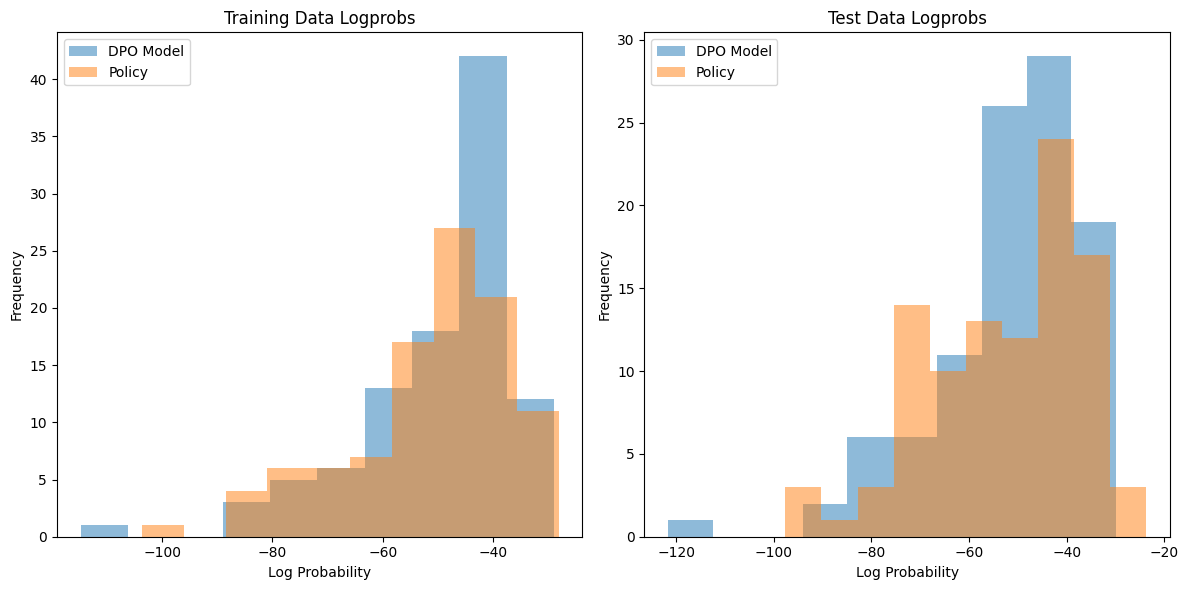

DPO Model - Train mean: -49.59, Test mean: -51.96
Base Policy - Train mean: -51.13, Test mean: -52.64

Train data p-value: 0.4545 (not significant)
Test data p-value: 0.7477 (not significant)


In [15]:
import matplotlib.pyplot as plt

dpo_model = AutoModelForCausalLM.from_pretrained(
    'CTOHbl4/llm-course-hw2-dpo',
    attn_implementation="sdpa",
    torch_dtype=torch.bfloat16,
    device_map="cuda"
)
dpo_tokenizer = AutoTokenizer.from_pretrained('CTOHbl4/llm-course-hw2-dpo')

policy = AutoModelForCausalLM.from_pretrained(
    "CTOHbl4/llm-course-hw2-ppo",
    device_map="cuda"
)
tokenizer = AutoTokenizer.from_pretrained("CTOHbl4/llm-course-hw2-ppo", padding_side="left")
tokenizer.pad_token = tokenizer.eos_token

dataset = load_dataset(DATASET_ID, split="train")
dataset = dataset.train_test_split(train_size=0.9)

def calculate_logprobs(model, tokenizer, dataset, num_samples=100):
    """Вычисляет лог-вероятности для выборки данных"""
    logprobs = []
    for example in tqdm(dataset.shuffle().select(range(num_samples))):
        # Токенизация с учетом шаблона чата
        messages = [{"role": "user", "content": example["prompt"]}]
        text = tokenizer.apply_chat_template(messages, tokenize=False)
        inputs = tokenizer(text, return_tensors="pt").to("cuda")

        with torch.no_grad():
            outputs = model(**inputs, labels=inputs["input_ids"])
            logprob = -outputs.loss * inputs["input_ids"].shape[1]
            logprobs.append(logprob.item())

    return logprobs

dpo_train_logprobs = calculate_logprobs(dpo_model, dpo_tokenizer, dataset["train"])
dpo_test_logprobs = calculate_logprobs(dpo_model, dpo_tokenizer, dataset["test"])
policy_train_logprobs = calculate_logprobs(policy, tokenizer, dataset["train"])
policy_test_logprobs = calculate_logprobs(policy, tokenizer, dataset["test"])

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(dpo_train_logprobs, alpha=0.5, label='DPO Model')
plt.hist(policy_train_logprobs, alpha=0.5, label='Policy')
plt.title('Training Data Logprobs')
plt.xlabel('Log Probability')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(dpo_test_logprobs, alpha=0.5, label='DPO Model')
plt.hist(policy_test_logprobs, alpha=0.5, label='Policy')
plt.title('Test Data Logprobs')
plt.xlabel('Log Probability')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

print(f"DPO Model - Train mean: {np.mean(dpo_train_logprobs):.2f}, Test mean: {np.mean(dpo_test_logprobs):.2f}")
print(f"Base Policy - Train mean: {np.mean(policy_train_logprobs):.2f}, Test mean: {np.mean(policy_test_logprobs):.2f}")

from scipy import stats
train_t, train_p = stats.ttest_rel(dpo_train_logprobs, policy_train_logprobs)
test_t, test_p = stats.ttest_rel(dpo_test_logprobs, policy_test_logprobs)
print(f"\nTrain data p-value: {train_p:.4f} ({'significant' if train_p < 0.05 else 'not significant'})")
print(f"Test data p-value: {test_p:.4f} ({'significant' if test_p < 0.05 else 'not significant'})")


#**Выводы:**

1) На трейне и тесте модели ведут себя одинаково статистически.

2) По графикам видно, что argmax{frequency(logprob)} у модели PPO на трейне чуть больше, чем на тесте (примерно -40 > -48) (можно говорить о незначительном переобучении).

3) У модели DPO на трейне и тесте argmax{frequency(logprob)} совпадает (взяты малые значения beta и lr).

4) Отмечу, что при числе эпох 2 ppo настолько переобучилось, что начало спамить одно слово.

5) У dpo с предложенными изначально параметрами (beta=1, lr=1e-5) наблюдалось переобучение (после буквально пары батчей метрики уже были на максимальных значениях). Поэтому параметры были уменьшены.

# Дополнительные баллы

Вы также можно заработать дополнительные баллы:
- Оформить репозитории на 🤗 (можно сделать коллекцию, так как у нас 3 репозитория): карточка модели с описанием задания, репортом качества и примерами генерации **[2 балла]**

# Специальный раздел для проверяющего

In [16]:
device = torch.device("cuda")

DPO_REPO_NAME = f"{REPO_NAME}-dpo"
PPO_REPO_NAME = f"{REPO_NAME}-ppo"
REWARD_MODEL_REPO_NAME = f"{REPO_NAME}-reward-model"

tokenizer = AutoTokenizer.from_pretrained(DPO_REPO_NAME)
check_model = AutoModelForCausalLM.from_pretrained(DPO_REPO_NAME)
check_model = check_model.to(device)
check_model = check_model.eval()

In [22]:
messages = [{"role": "user", "content": "What's your morning routine like?"}]

text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
model_inputs = tokenizer([text], return_tensors="pt").to(device)

generated_ids = check_model.generate(model_inputs.input_ids, max_new_tokens=256, do_sample=False)
response = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
print(response)

user
What's your morning routine like?
assistant
I'm excited to share my morning routine with you! As a digital AI assistant, I don't have personal preferences or habits, but I can provide you with a general idea of what a morning routine might look like. Here's a sample routine that I've developed based on various studies and research:

**Morning Routine (10-15 minutes)**

1. **Hydrate**: Drink a full glass of water or a herbal tea (e.g., chamomile, peppermint) to start the day.
2. **Eat a nutritious breakfast**: Prepare a healthy breakfast, such as oatmeal with fruit, scrambled eggs with spinach, or Greek yogurt with berries.
3. **Get some morning sunlight**: Spend 10-15 minutes outside in natural light to help regulate your circadian rhythms.
4. **Stretch or move**: Engage in some light stretching or physical activity, such as yoga or a short walk, to get your blood flowing and your body moving.
5. **Take a few deep breaths**: Take a few deep breaths to calm your mind and body.

**M